# Mesh resolution

In [1]:
from lucifex.solver import OptionsPETSc
from lucifex.fdm import AB, CN
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.viz import plot_colormap, plot_line, set_ipynb_variable
from lucifex.utils.array_utils import as_index
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

Nx_opts = (60, 60, 50) #(60, 120, 120, 160, 160, 180)
Ny_opts = (60, 50, 50) #(60, 60, 120, 120, 160, 180)
CELL_TYPE = 'quadrilateral'
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 600)
t_stop = 20.0
dt_init = 1e-6
n_init = 10

def _serialize(sim):
    sim_grid = as_grid_simulation(sim)
    cMax = sim_grid['cMinMax'].sub(1)
    import os
    pid = os.getpid()
    print(pid, 'max', max(cMax.value_series))
    print(pid, 'min', min(cMax.value_series))
    return cMax.time_series, cMax.value_series

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=_serialize, link=True,
    max_nbytes=None, 
    mmap_mode=None, 
)(
    cell=CELL_TYPE,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN,
    D_diff=AB(1)@CN,
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    c_stabilization=None,
    c_limits=None,
    c_petsc=OptionsPETSc('gmres', 'ilu'),
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)(
    Nx=Nx_opts,
    Ny=Ny_opts,
)

83529 max 1.0553033038514201
83529 min 9.967222305033854e-07
83528 max 1.0376244881429937
83528 min 9.967222305033854e-07
83527 max 1.0389157033908327
83527 min 9.999260456125832e-07


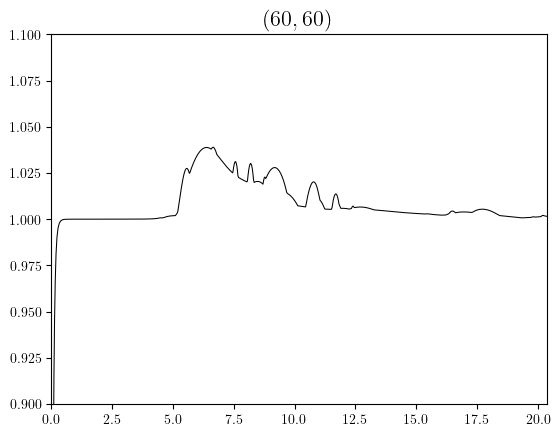

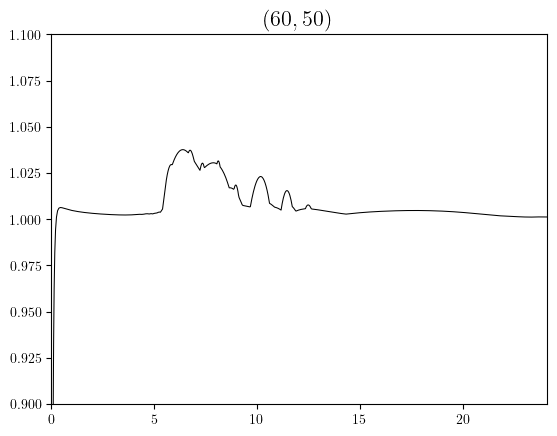

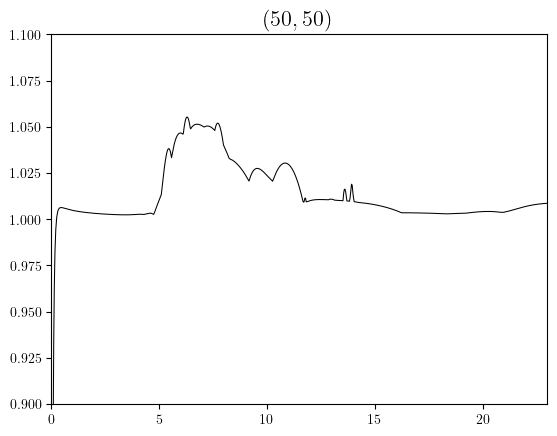

In [2]:
for (Nx, Ny), sim in simulations.items():
    title = f'$({Nx}, {Ny})$'
    # _ = sim['cMinMax'].sub(1)
    # print(max(_.value_series))
    plot_line(sim, title=title, y_lims=(1-0.1, 1+0.1),)

In [ ]:
uMax_lines, uRMS_lines, labels = [], [], []
legend_title = f'$\\texttt{{cell={CELL_TYPE}}}$\n$(N_x, N_y)$'

t_target = 2.0
cmap_funcs, cmap_titles = [], []

for (Nx, Ny), sim in simulations.items():
    label = f'$({Nx}, {Ny})$'
    labels.append(label)
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, t_target)
    cmap_funcs.append(c.series[time_index])
    cmap_titles.append(f'{legend_title}$ = ${label}\n$c(t={c.time_series[time_index]})$')

fig, ax = plot_line(
    uMax_lines,
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    legend_labels=labels,
    legend_title=legend_title,
)

fig, ax = plot_line(
    uRMS_lines,
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
    legend_labels=labels,
    legend_title=legend_title,
)

# for func, title in zip(cmap_funcs, cmap_titles):
#     fig, ax = plot_colormap(func, title=title)